# Model Training and Evaluation – Concepts

This notebook summarises the concepts and adds explanations and small examples. All examples use small hand-made numbers or simulated data – no data set is loaded.

**Contents**
1. What is machine learning?
2. Learning paradigms and the map of methods
3. Loss functions
4. Loss, training objective and evaluation metric
5. Train/test split and k-fold cross-validation
6. Under- and overfitting
7. The bias–variance trade-off

## Libraries and settings

In [15]:
# Libraries
import os
import platform
import warnings
from datetime import datetime
from platform import python_version

import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold

# Ignore warnings
warnings.filterwarnings('ignore')

## 1. What is machine learning?

> *"A computer program is said to learn from experience E with respect to some class of tasks T and performance measure
> P, if its performance at tasks in T, as measured by P, improves with experience E."* — T. Mitchell (1997)

**In data-science terms**
- **Data:** $n$ examples (rows), each with features $x$ (e.g. living area, rooms) and – in supervised learning – a
  known answer $y$ (e.g. rent).
- **Goal:** learn a rule $\hat y = \hat f(x)$ that also gives good answers for **new** examples.

**Typical applications:** price prediction (real estate, stocks), predictive maintenance (will the machine fail?),
fraud and spam detection, recommendation (bought X → also Y), customer segmentation, perception (speech, images,
driving).

## 2. Learning paradigms and the map of methods

| paradigm | data | goal | in this course |
|:---|:---|:---|:---|
| **Supervised** | labelled pairs $(x, y)$ | learn a rule $\hat y = \hat f(x)$ that predicts the known answer | regression, classification |
| **Unsupervised** | only $x$ | find groups or patterns | clustering, PCA |
| **Reinforcement** | agent & environment | learn a strategy (actions → rewards) | not covered (games, robotics, LLM fine-tuning) |

**Map of the methods**

| aspect | regression models | classification models | unsupervised learning |
|:---|:---|:---|:---|
| target $y$ | a number (CHF, kg, minutes) | a category (yes/no, A/B/C) | none – only features $x$ |
| question | How much? | Which class? | Which groups / patterns? |
| methods | linear regression, regression tree, random forest, boosting | logistic regression, classification tree, random forest, boosting, k-NN, Naive Bayes, SVM | k-means, hierarchical clustering, PCA |
| evaluation | RMSE, $R^2$ on test data | accuracy, precision, recall, ROC/AUC | elbow plot, stability, interpretation |
| example | rent of an apartment | survived the Titanic? | customer segments |

**Regression vs. classification** – same workflow, different target:

| $y$ (label) | colour | height [cm] | weight [kg] |
|:---|:---|:---|:---|
| cat | yellow | 42 | 2.5 |
| dog | black | 85 | 55.0 |
| dog | yellow | 35 | 4.5 |
| cat | black | 40 | 2.3 |

Here $y$ is a category → classification. If $y$ were the weight, it would be regression.

**A short history:** 1763 Bayes' theorem · 1805 least squares (Legendre, Gauss) · 1936 Turing machine · 1957
perceptron (Rosenblatt) · 1967 nearest neighbours (Cover & Hart) · 1984 CART (Breiman et al.) · 1990 boosting
(Schapire) · 1995 SVM (Cortes & Vapnik) · 2001 random forests (Breiman) · 2017 Transformer (Vaswani et al.).

## 3. Loss functions: learning = minimising a loss

A **loss** measures the error of *one* prediction. **Training** chooses the model with the smallest **average loss**
over the $n$ training examples:

$$\hat f = \arg\min_f \; \frac{1}{n}\sum_{i=1}^{n} L\big(y_i, f(x_i)\big)$$

| task | loss | formula | property |
|:---|:---|:---|:---|
| regression | squared loss | $(y-\hat y)^2$ | error 2 → 4, error 10 → 100: large errors weigh heavily (outlier-sensitive) |
| regression | absolute loss | $\lvert y-\hat y\rvert$ | grows linearly, more robust |
| classification | 0-1 loss | $1$ if wrong, $0$ if correct | what we count, but not smooth |
| classification | log-loss | $\log(1+e^{-m})$ | smooth, convex (logistic regression) |
| classification | hinge loss | $\max(0, 1-m)$ | convex, kink at $m=1$ (SVM) |

For classification with labels $y \in \{-1, +1\}$ and a score $s$, the **margin** $m = y \cdot s$ is positive if the
prediction is on the correct side. Log-loss and hinge loss are convex stand-ins for the 0-1 loss; both also penalise
"barely correct" predictions ($0 < m < 1$).

**What we actually care about** is the error on **new, unseen** data (the *generalisation error*). It cannot be computed
directly – we estimate it on data that were not used for fitting. The training error is typically **optimistically
biased**, because the same data were used to fit the model.

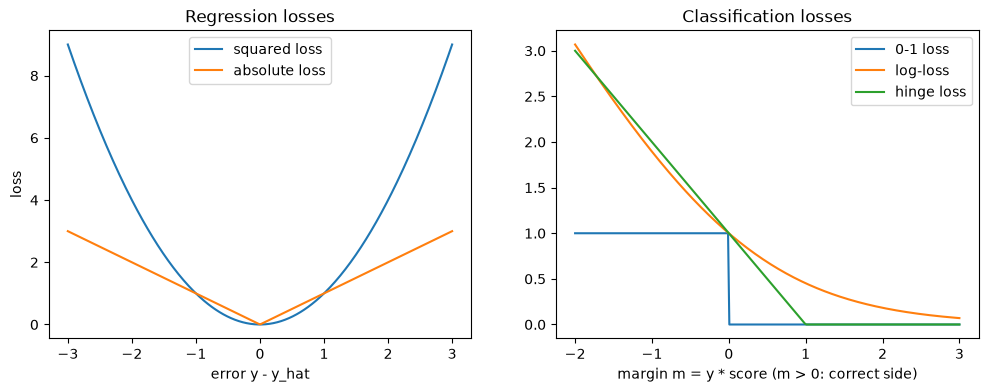

In [16]:
# Values for the x-axes of the two plots
error = np.linspace(-3, 3, 300)  # error y - y_hat (regression)
margin = np.linspace(-2, 3, 300)  # margin y * score (classification)

# Figure showing loss functions for regression and classification
plt.figure(figsize=(12, 4))

# Left: regression losses as a function of the error
plt.subplot(1, 2, 1)
plt.plot(error, error**2, label='squared loss')
plt.plot(error, np.abs(error), label='absolute loss')
plt.xlabel('error y - y_hat')
plt.ylabel('loss')
plt.title('Regression losses')
plt.legend()

# Right: classification losses as a function of the margin
plt.subplot(1, 2, 2)
plt.plot(margin, np.where(margin <= 0, 1, 0), label='0-1 loss')
plt.plot(margin, np.log2(1 + np.exp(-margin)), label='log-loss')
plt.plot(margin, np.maximum(0, 1 - margin), label='hinge loss')
plt.xlabel('margin m = y * score (m > 0: correct side)')
plt.title('Classification losses')
plt.legend()
plt.show()

**A graphical example.** Every candidate model has an average loss.
Training means searching for the parameter value at the bottom of the loss curve. Below we simulate rents of apartments and
compute the MSE of lines with different slopes (the intercept is chosen optimally for each slope). The minimum is the
OLS solution.

Line A: slope 15,  MSE = 210000
Line B: slope 28.4  MSE = 31408
Line C: slope 45,  MSE = 299127


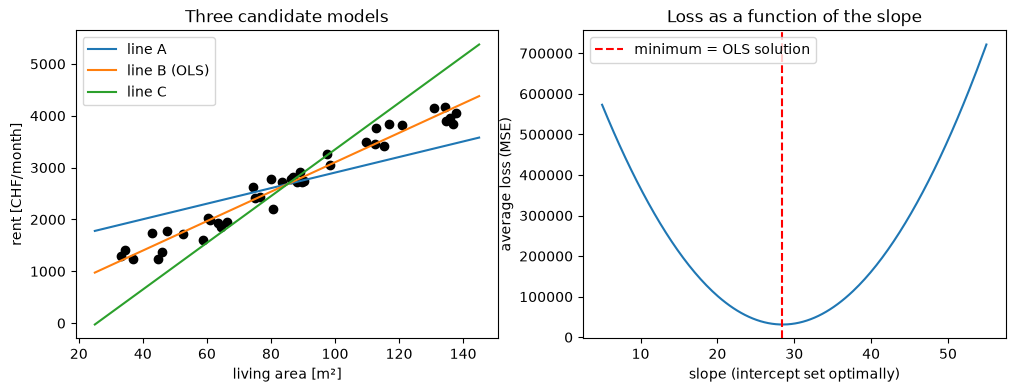

In [17]:
# Simulate the rents of 40 apartments
rng = np.random.default_rng(1)
area = rng.uniform(30, 140, 40)
rent = 160 + 30 * area + rng.normal(0, 250, 40)


# Function: computes the MSE of a line with this slope and the best intercept
def mse_for_slope(slope):
    """MSE of the line with this slope and the best intercept."""
    intercept = np.mean(rent - slope * area)
    return np.mean((rent - intercept - slope * area) ** 2)


# MSE for 200 slopes between 5 and 55
slopes = np.linspace(5, 55, 200)
mse = []
for slope in slopes:
    mse.append(mse_for_slope(slope))

# The slope with the smallest MSE is the OLS solution (line B)
best = slopes[np.argmin(mse)]
print('Line A: slope 15,  MSE =', round(mse_for_slope(15)))
print('Line B: slope', round(best, 1), ' MSE =', round(mse_for_slope(best)))
print('Line C: slope 45,  MSE =', round(mse_for_slope(45)))

# Figure showing the three lines (left) and the MSE of every slope (right)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(area, rent, color='black')
x = np.array([25, 145])
for name, slope in [('A', 15), ('B (OLS)', best), ('C', 45)]:
    intercept = np.mean(rent - slope * area)
    plt.plot(x, intercept + slope * x, label='line ' + name)
plt.xlabel('living area [m²]')
plt.ylabel('rent [CHF/month]')
plt.title('Three candidate models')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(slopes, mse)
plt.axvline(best, color='red', linestyle='--', label='minimum = OLS solution')
plt.xlabel('slope (intercept set optimally)')
plt.ylabel('average loss (MSE)')
plt.title('Loss as a function of the slope')
plt.legend()
plt.show()

## 4. Loss, training objective and evaluation metric

| term | meaning | examples |
|:---|:---|:---|
| **loss** | error of ONE prediction | $(y-\hat y)^2$, log-loss, hinge, 0-1 |
| **training objective** | what the algorithm optimises | average loss (+ penalty) or a split criterion |
| **evaluation metric** | how we judge the model on new data | RMSE, $R^2$, accuracy, F1, AUC |

**What the models in this course minimise and how they are evaluated:**

| model | training objective (what is minimised) | typical evaluation metric |
|:---|:---|:---|
| linear regression (OLS) | sum of squared errors (RSS) | RMSE, $R^2$ on test data |
| logistic regression | log-loss = negative log-likelihood | accuracy, F1, AUC |
| decision tree (CART) | greedy: largest decrease in SSE / Gini / entropy per split | regression: RMSE; classification: accuracy, F1, AUC |
| SVM | hinge loss + $\lVert w\rVert^2$ penalty | accuracy, AUC |
| gradient boosting | any differentiable loss (squared, log-loss, …) | depends on the task |

**Key idea:** the objective we optimise and the metric we report need not be the same. A model is fitted with a loss that
is convenient to optimise (smooth, convex), but judged with a metric that is meaningful for the application.

## 5. Train/test split and k-fold cross-validation

**Hold-out split.** The data are split once into a **training set** (e.g. 80 %: fit the model, tune hyperparameters) and
a **test set** (e.g. 20 %). The test set is used **only once at the very end** – otherwise the test error is no longer an
honest estimate.

**k-fold cross-validation** (on the training set, e.g. $k = 5$): split the training data into $k$ folds; fit on $k-1$
folds and validate on the remaining one; repeat $k$ times so that each fold is used once for validation:

$$\text{CV error} = \frac{1}{k}\sum_{j=1}^{k} \text{MSE}_j$$

In [18]:
# 5-fold cross-validation for 20 observations
kf = KFold(n_splits=5, shuffle=True, random_state=0)
observations = np.arange(1, 21)

# Each run validates on one fold and trains on the other four folds
run = 1
for train_index, val_index in kf.split(observations):
    print('Run', run, '- validate on observations', observations[val_index])
    run = run + 1

Run 1 - validate on observations [ 2  9 19 20]
Run 2 - validate on observations [ 7 11 14 18]
Run 3 - validate on observations [ 3  5  6 15]
Run 4 - validate on observations [ 8 10 12 17]
Run 5 - validate on observations [ 1  4 13 16]


## 6. Under- and overfitting

- **Underfitting:** model too simple – high error on training *and* test data.
- **Good fit:** captures the signal, ignores the noise.
- **Overfitting:** learns the noise – low training error, high test error.

The example below fits polynomials of degree 1, 4 and 15 to 18 noisy points of a sine curve.

Degree 1 - train MSE: 0.186   test MSE: 0.223
Degree 4 - train MSE: 0.033   test MSE: 0.07
Degree 15 - train MSE: 0.023   test MSE: 58.233


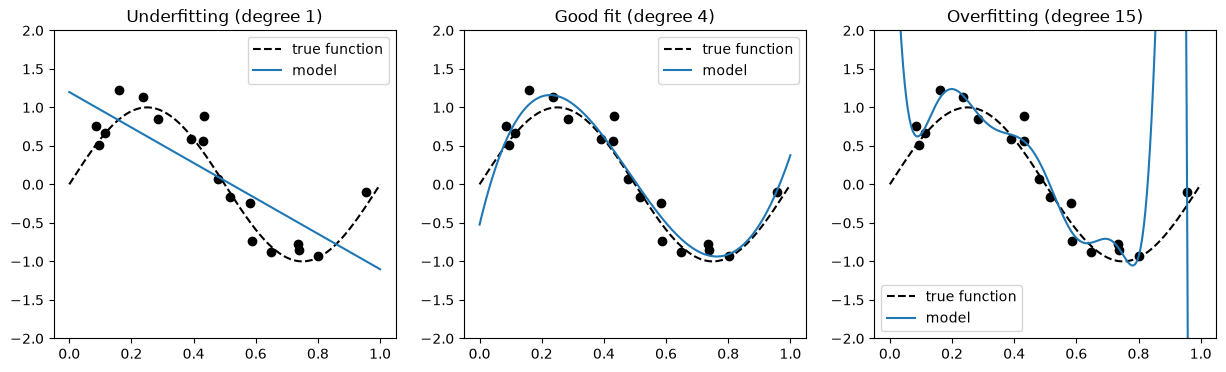

In [19]:
# Simulate 18 training points and 200 test points (sine curve + noise)
rng = np.random.default_rng(3)
x = np.sort(rng.uniform(0, 1, 18))
y = np.sin(2 * np.pi * x) + rng.normal(0, 0.25, 18)
x_test = rng.uniform(0, 1, 200)
y_test = np.sin(2 * np.pi * x_test) + rng.normal(0, 0.25, 200)

# scikit-learn expects the features as a table with one column
X = x.reshape(-1, 1)
X_test = x_test.reshape(-1, 1)
x_grid = np.linspace(0, 1, 400)


# Function: builds a model with x, x², ..., x^degree and a linear regression
def poly_model(degree):
    """Polynomial regression model of the given degree."""
    return make_pipeline(
        PolynomialFeatures(degree, include_bias=False),
        StandardScaler(),
        LinearRegression(),
    )


# Figure showing the fits of degree 1, 4 and 15
plt.figure(figsize=(15, 4))
titles = ['Underfitting', 'Good fit', 'Overfitting']
for i, degree in enumerate([1, 4, 15]):
    model = poly_model(degree).fit(X, y)

    # Training and test error
    train_mse = np.mean((y - model.predict(X)) ** 2)
    test_mse = np.mean((y_test - model.predict(X_test)) ** 2)
    print(
        'Degree',
        degree,
        '- train MSE:',
        round(train_mse, 3),
        '  test MSE:',
        round(test_mse, 3),
    )

    # One plot per degree
    plt.subplot(1, 3, i + 1)
    plt.plot(x_grid, np.sin(2 * np.pi * x_grid), 'k--', label='true function')
    plt.plot(x_grid, model.predict(x_grid.reshape(-1, 1)), label='model')
    plt.scatter(x, y, color='black')
    plt.ylim(-2, 2)
    plt.title(titles[i] + ' (degree ' + str(degree) + ')')
    plt.legend()
plt.show()

## 7. The bias–variance trade-off

For squared-error loss, the expected test error at a point $x$ decomposes into three parts:

$$E\big[(y-\hat f(x))^2\big] = \underbrace{\big(E[\hat f(x)] - f(x)\big)^2}_{\text{Bias}^2}
+ \underbrace{E\big[(\hat f(x) - E[\hat f(x)])^2\big]}_{\text{Variance}} + \underbrace{\sigma^2}_{\text{noise}}$$

- **Bias:** error from too simple assumptions – the model is *systematically* wrong.
- **Variance:** error from instability – the model changes a lot with another training sample.
- **Noise:** the part no model can remove.
- **Goal:** minimise the **sum** – not either term alone.

Example: predicting every rent by the overall mean → high bias; a degree-15 polynomial through 18 apartments → high variance.

The simulation below fits each polynomial degree on 300 training samples of 40 points and estimates bias² and variance.

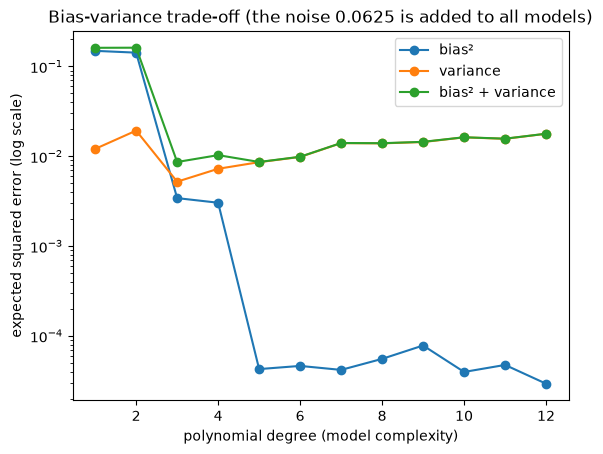

In [20]:
# Points where we compare the models with the true function
rng = np.random.default_rng(0)
x_eval = np.linspace(0.1, 0.9, 50)
f_true = np.sin(2 * np.pi * x_eval)

# For each degree: fit the model on 300 training samples of 40 points
degrees = range(1, 13)
bias2 = []
variance = []
for degree in degrees:
    predictions = []
    for _ in range(300):
        xs = rng.uniform(0, 1, 40)
        ys = np.sin(2 * np.pi * xs) + rng.normal(0, 0.25, 40)
        model = poly_model(degree).fit(xs.reshape(-1, 1), ys)
        predictions.append(model.predict(x_eval.reshape(-1, 1)))
    predictions = np.array(predictions)

    # Bias²: how far the average prediction is from the true function
    bias2.append(np.mean((predictions.mean(axis=0) - f_true) ** 2))
    # Variance: how much the predictions vary around their average
    variance.append(np.mean(predictions.var(axis=0)))

# Figure showing bias², variance and their sum by polynomial degree
total = np.array(bias2) + np.array(variance)
plt.plot(degrees, bias2, marker='o', label='bias²')
plt.plot(degrees, variance, marker='o', label='variance')
plt.plot(degrees, total, marker='o', label='bias² + variance')
plt.yscale('log')
plt.xlabel('polynomial degree (model complexity)')
plt.ylabel('expected squared error (log scale)')
plt.title('Bias-variance trade-off (the noise 0.0625 is added to all models)')
plt.legend()
plt.show()

**Reading the plot:** bias² decreases with the model complexity (from degree 3 on the sine shape is captured), variance
increases. Their sum – the part of the expected test error that the model can influence; the noise is the same for all
models – is smallest for a medium complexity (here around degree 3–5). How quickly the variance grows depends on the amount of data: with more training
observations, flexible models become more stable.

**Ways to reduce the variance:** more data, simpler models, regularisation / pruning, averaging many models (bagging,
random forest). **Ways to reduce the bias:** more flexible models, better features.

**Key messages**
- The training error is optimistically biased – estimate the generalisation error on unseen data.
- Choose the complexity with cross-validation; use the test set only once.
- Under- and overfitting are two sides of the bias–variance trade-off.

### Jupyter notebook --footer info-- (please always provide this at the end of each notebook)

In [21]:
# Show operating system, date/time and Python version
print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Linux | 6.8.0-1064-azure
Datetime: 2026-10-02 15:38:23
Python Version: 3.11.16
-----------------------------------
